# Generate UMAP embeddings and plots

We replicate the same process of generating UMAP embeddings that was done in the original LINCS paper, but with and without QC.

In [1]:
import pathlib
import numpy as np
import pandas as pd
import umap

from sklearn.decomposition import PCA
from pycytominer.cyto_utils import infer_cp_features

from plotnine import (
    ggplot,
    aes,
    geom_point,
    ggtitle,
    xlab,
    ylab,
    guides,
    guide_legend,
    theme_bw,
    scale_color_gradientn,
    scale_size_manual,
    scale_alpha_manual,
    scale_color_manual,
    scale_color_gradient,
    scale_shape_manual,
    scale_color_brewer,
)

In [2]:
np.random.seed(42)

In [3]:
# Output file info
output_dir = pathlib.Path("./embeddings")
output_dir.mkdir(parents=True, exist_ok=True)
pre_qc_output_file = pathlib.Path(f"{output_dir}/whole_batch_pre_qc_embeddings.parquet")
post_qc_output_file = pathlib.Path(
    f"{output_dir}/whole_batch_post_qc_embeddings.parquet"
)

# Figure output directory
figure_output_dir = pathlib.Path("./figures")
figure_output_dir.mkdir(parents=True, exist_ok=True)

# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

## Load in pre-QC and post-QC profiles

In [4]:
# Load in pre-QC cell painting profile
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)

# Load in post-QC cell painting profile
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Print out pre_qc_df shape and head
print(f"Pre-QC df shape: {pre_qc_df.shape}")
pre_qc_df.head()

Pre-QC df shape: (51833, 808)


,Metadata_broad_sample,Metadata_pert_id,Metadata_Plate,Metadata_Well,Metadata_broad_id,Metadata_moa,Metadata_dose_recode,Metadata_sc_count,Cytoplasm_AreaShape_Eccentricity,Cytoplasm_AreaShape_FormFactor,...,Nuclei_Texture_SumVariance_RNA_20_0,Nuclei_Texture_Variance_DNA_20_0,Nuclei_Texture_Variance_ER_20_0,Nuclei_Texture_Variance_RNA_10_0,Nuclei_Texture_Variance_RNA_20_0,broad_id,pert_iname,moa,replicate_name,Metadata_sc_count_failed_qc
0,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B07,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,6,1019,-2.426162,1.387065,...,-0.159945,2.455512,0.425172,-1.257170,0.295887,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_0,287.0
1,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B08,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,5,1006,-2.932106,0.367342,...,-0.805960,2.546461,-0.047052,-0.718739,-0.331851,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_1,260.0
2,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B09,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,4,1257,0.687615,-0.264883,...,-1.654745,-0.194943,-0.861276,-1.353638,-0.790740,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_2,389.0
3,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B10,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,3,1209,-1.026552,-0.219168,...,-0.953736,0.706355,-0.036504,-0.316320,-0.272585,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_3,440.0
4,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B11,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,2,1238,-1.085517,-1.131722,...,-1.836758,-0.480219,-1.160900,-0.303018,-0.694332,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_4,479.0


## Pre-QC UMAPs (Panels A and B)

In [5]:
cp_features = infer_cp_features(pre_qc_df)
meta_features = [
    *infer_cp_features(pre_qc_df, metadata=True),
    "broad_id",
    "pert_iname",
    "moa",
    "replicate_name",
]

# Transform PCA to top 50 components
# This is performed in the original LINCS Cell Painting paper to generate
# Figure 2 of the paper at this GitHub link:
# https://github.com/broadinstitute/lincs-profiling-complementarity/blob/5091585bde14c33d6819fa6b494e352a064fbeb4/1.Data-exploration/Profiles_level4/cell_painting/scripts/nbconverted/10.cellpainting_manifold.py#L12
n_components = 50
pca = PCA(n_components=n_components)

pre_qc_pca_df = pca.fit_transform(pre_qc_df.loc[:, cp_features])
pre_qc_pca_df = pd.DataFrame(pre_qc_pca_df)
pre_qc_pca_df.columns = [f"PCA_{x}" for x in range(0, n_components)]

print(pre_qc_pca_df.shape)
pre_qc_pca_df.head()

(51833, 50)


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_40,PCA_41,PCA_42,PCA_43,PCA_44,PCA_45,PCA_46,PCA_47,PCA_48,PCA_49
0,-38.626784,4.283050,0.417612,-2.930790,4.988105,-5.532358,-6.145365,-6.078005,4.242792,-0.929343,...,0.816197,1.599838,-2.646810,3.208144,-1.801313,1.483092,1.371340,-4.106815,-2.644666,-1.785478
1,-39.183534,0.904438,-4.815307,-0.903914,0.704686,-5.880837,-4.989218,-4.295204,3.428445,-2.529323,...,-1.222162,4.299333,-3.870541,1.130691,1.774132,0.190887,-1.801122,-2.339605,-2.768899,-0.656033
2,-38.867161,5.557426,-0.320652,-2.809038,1.777620,-4.154940,-1.831647,-3.568998,1.612867,1.268594,...,0.965480,-3.148536,-1.905514,-1.262868,0.236853,0.423739,-0.130765,-3.698979,0.780691,1.897230
3,-39.744100,5.768950,-3.309256,0.155196,0.371114,-2.019374,-6.150060,-6.177059,1.328503,1.833085,...,0.657531,-0.842839,-3.867291,-3.312258,1.286149,0.262327,2.615671,0.584800,-2.744457,-1.263001
4,-41.093499,5.871909,-1.039278,0.643555,-0.780684,-3.959697,-7.573796,-1.894780,0.046298,-0.349294,...,0.827866,1.013340,2.080239,1.202851,0.014171,-0.530652,0.900862,-0.033345,0.341927,0.026685


In [6]:
# Fit UMAP directly on CellProfiler features
reducer = umap.UMAP(random_state=123, min_dist=0.1, n_neighbors=20, metric="euclidean")
pre_qc_embedding_df = reducer.fit_transform(
    pre_qc_pca_df.drop(["PCA_0"], axis="columns")
)

pre_qc_embedding_df = pd.DataFrame(pre_qc_embedding_df)
pre_qc_embedding_df.columns = ["UMAP_0", "UMAP_1"]
pre_qc_embedding_df = pd.concat(
    [pre_qc_df.loc[:, meta_features], pre_qc_embedding_df], axis="columns"
)

pre_qc_embedding_df.head()

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


,Metadata_broad_sample,Metadata_pert_id,Metadata_Plate,Metadata_Well,Metadata_broad_id,Metadata_moa,Metadata_dose_recode,Metadata_sc_count,Metadata_sc_count_failed_qc,broad_id,pert_iname,moa,replicate_name,UMAP_0,UMAP_1
0,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B07,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,6,1019,287.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_0,-0.482368,3.187088
1,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B08,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,5,1006,260.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_1,-2.239089,1.803744
2,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B09,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,4,1257,389.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_2,-1.006554,4.047884
3,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B10,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,3,1209,440.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_3,-1.747416,4.096642
4,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B11,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,2,1238,479.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_4,-2.204118,2.275185


In [7]:
# --- Select MOA targets (key = lowercase name, value = display label) ---
moa_targets = {
    "aurora kinase inhibitor": "Aurora kinase inhibitor",
    "plk inhibitor": "PLK inhibitor",
    "proteasome inhibitor": "Proteasome inhibitor",
    "exportin antagonist": "Exportin antagonist",
    "maternal embryonic leucine zipper kinase inhibitor": "MELK inhibitor",
    "tubulin inhibitor": "Tubulin inhibitor",
    "hsp inhibitor": "HSP inhibitor",
    "xiap inhibitor": "XIAP inhibitor",
    "other": "Other",
}

# --- Create compounds to highlight ---
# Use display labels directly (values of the dict)
moa_labels = list(moa_targets.values())

moa_targets_size_values = dict.fromkeys(moa_labels[:-1], 1)
moa_targets_size_values[moa_labels[-1]] = 0.1

moa_targets_alpha_values = dict.fromkeys(moa_labels[:-1], 0.5)
moa_targets_alpha_values[moa_labels[-1]] = 0.1

In [8]:
# Add DMSO label to dataframe
pre_qc_embedding_df = pre_qc_embedding_df.assign(dmso_label="DMSO")
pre_qc_embedding_df.loc[
    pre_qc_embedding_df.Metadata_broad_sample != "DMSO", "dmso_label"
] = "compound"

# --- Add highlight_moa column ---
pre_qc_embedding_df = pre_qc_embedding_df.assign(
    highlight_moa=pre_qc_embedding_df["moa"].str.lower().map(moa_targets)
)
pre_qc_embedding_df["highlight_moa"] = pre_qc_embedding_df["highlight_moa"].fillna(
    "Other"
)

pre_qc_embedding_df.head()

,Metadata_broad_sample,Metadata_pert_id,Metadata_Plate,Metadata_Well,Metadata_broad_id,Metadata_moa,Metadata_dose_recode,Metadata_sc_count,Metadata_sc_count_failed_qc,broad_id,pert_iname,moa,replicate_name,UMAP_0,UMAP_1,dmso_label,highlight_moa
0,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B07,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,6,1019,287.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_0,-0.482368,3.187088,compound,Other
1,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B08,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,5,1006,260.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_1,-2.239089,1.803744,compound,Other
2,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B09,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,4,1257,389.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_2,-1.006554,4.047884,compound,Other
3,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B10,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,3,1209,440.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_3,-1.747416,4.096642,compound,Other
4,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B11,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,2,1238,479.0,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_4,-2.204118,2.275185,compound,Other


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/pre_qc_moa_umap.png


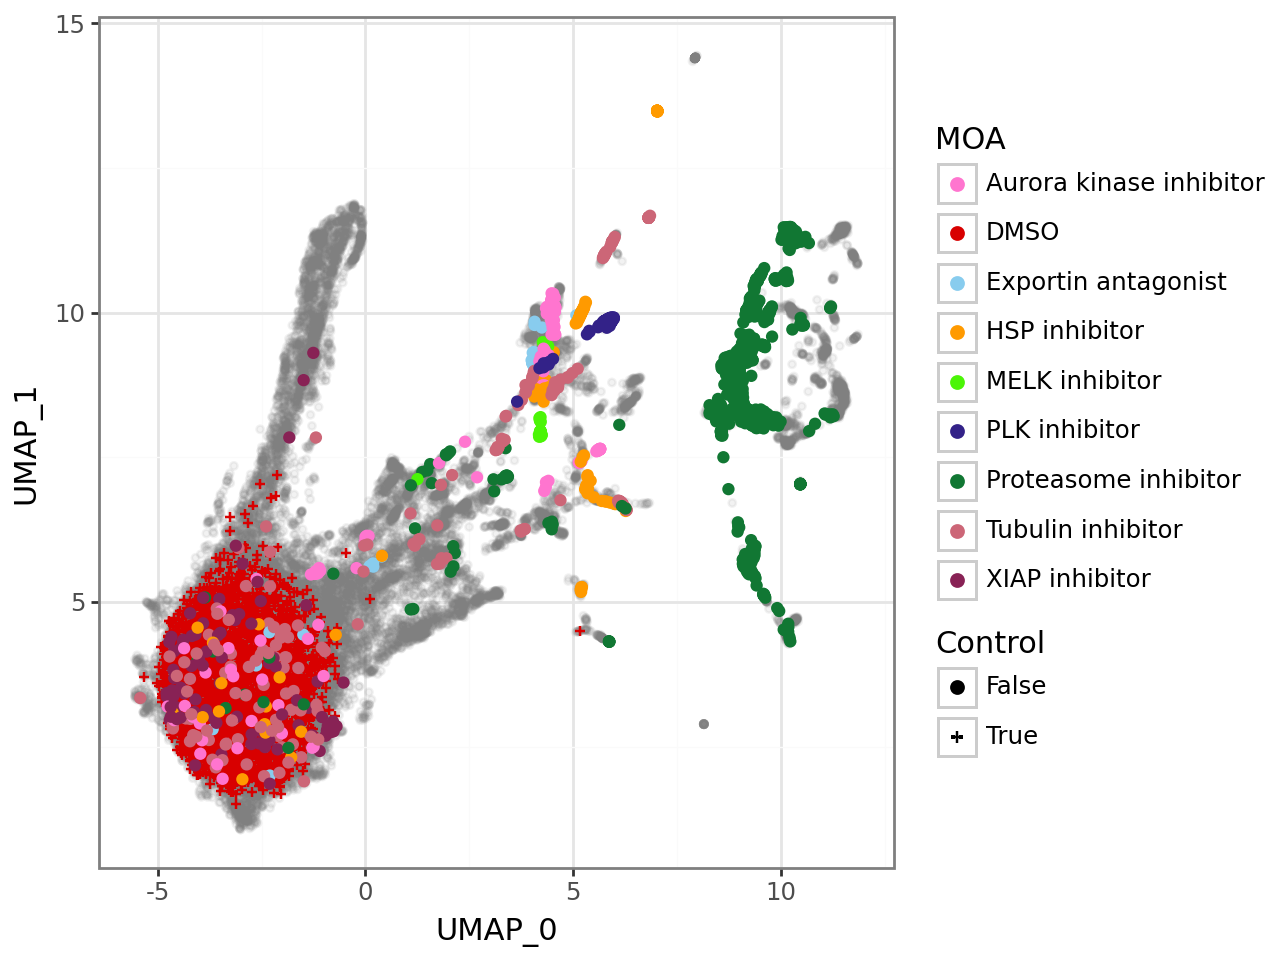

In [9]:
# Define colors for MOA categories
moa_colors = {
    "Aurora kinase inhibitor": "#ff75cf",
    "PLK inhibitor": "#332288",
    "Proteasome inhibitor": "#117733",
    "Exportin antagonist": "#88CCEE",
    "MELK inhibitor": "#4bf507",
    "Tubulin inhibitor": "#CC6677",
    "HSP inhibitor": "#FF9A00",
    "XIAP inhibitor": "#882255",
    "Other": "grey",
}

# 1. Create columns for plotting
pre_qc_embedding_df["is_control"] = pre_qc_embedding_df["dmso_label"] == "DMSO"

# Make a plotting MOA column so DMSO is separate from "Other"
pre_qc_embedding_df["plot_moa"] = pre_qc_embedding_df["highlight_moa"]
pre_qc_embedding_df.loc[pre_qc_embedding_df["dmso_label"] == "DMSO", "plot_moa"] = (
    "DMSO"
)

# Split datasets for layering
other_df = pre_qc_embedding_df.query("highlight_moa == 'Other' & dmso_label != 'DMSO'")
main_df = pre_qc_embedding_df.query("highlight_moa != 'Other' | dmso_label == 'DMSO'")

# 2. Build plot
p = (
    ggplot()
    # Layer 1: Other points in back, faint and small
    + geom_point(
        data=other_df,
        mapping=aes(x="UMAP_0", y="UMAP_1"),
        color=moa_colors["Other"],
        alpha=0.1,
        size=1,
        show_legend=False,
    )
    # Layer 2: All other MOAs + DMSO for correct legends
    + geom_point(
        data=main_df,
        mapping=aes(x="UMAP_0", y="UMAP_1", color="plot_moa", shape="is_control"),
    )
    # Titles and labels
    + xlab("UMAP_0")
    + ylab("UMAP_1")
    # Scales
    + scale_color_manual(name="MOA", values={**moa_colors, "DMSO": "#D80000"})
    + scale_shape_manual(name="Control", values={True: "+", False: "o"})
    # Guides
    + guides(
        shape=guide_legend(override_aes={"alpha": 1, "size": 2}),
        color=guide_legend(override_aes={"alpha": 1, "size": 2}),
    )
    # Theme
    + theme_bw()
)
p.save(filename=figure_output_dir / "pre_qc_moa_umap.png", dpi=600)
p.show()

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/pre_qc_failed_qc_umap.png


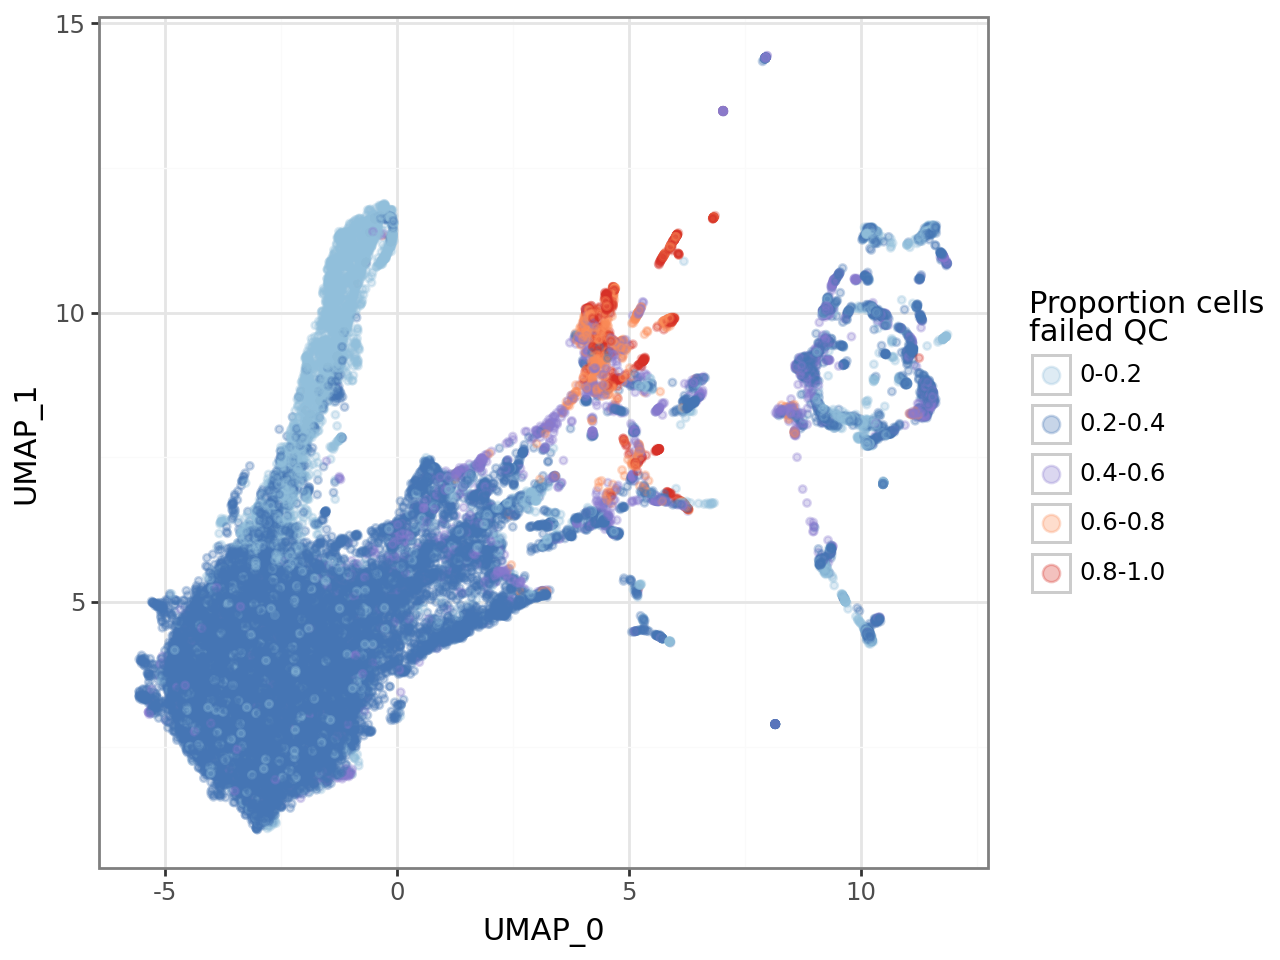

In [10]:
# Compute proportion failed
pre_qc_embedding_df["prop_failed_qc"] = (
    pre_qc_embedding_df["Metadata_sc_count_failed_qc"]
    / pre_qc_embedding_df["Metadata_sc_count"]
)

# Drop any rows with NaN in the proportion column
pre_qc_embedding_df = pre_qc_embedding_df.dropna(subset=["prop_failed_qc"])

# Clip to [0, 1] just in case any weird negatives or >1 sneak in
pre_qc_embedding_df["prop_failed_qc"] = pre_qc_embedding_df["prop_failed_qc"].clip(0, 1)

# Define fixed bins from 0-1
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

pre_qc_embedding_df["prop_failed_qc_bin"] = pd.cut(
    pre_qc_embedding_df["prop_failed_qc"], bins=bins, labels=labels, include_lowest=True
)
manual_colors = [
    "#91bfdb",  # light blue
    "#4575b4",  # dark blue
    "#8979cf",  # purple
    "#fc8d59",  # orange-red
    "#d73027",  # red
]

p_failed_qc = (
    ggplot(pre_qc_embedding_df, aes(x="UMAP_0", y="UMAP_1", color="prop_failed_qc_bin"))
    + geom_point(size=1, alpha=0.3)
    + xlab("UMAP_0")
    + ylab("UMAP_1")
    + scale_color_manual(values=manual_colors, name="Proportion cells\nfailed QC")
    + guides(color=guide_legend(override_aes={"size": 3}))  # increases legend dot size
    + theme_bw()
)
p_failed_qc.save(filename=figure_output_dir / "pre_qc_failed_qc_umap.png", dpi=600)
p_failed_qc.show()

## UMAP for post-QC

In [11]:
cp_features = infer_cp_features(post_qc_df)
meta_features = [
    *infer_cp_features(post_qc_df, metadata=True),
    "broad_id",
    "pert_iname",
    "moa",
    "replicate_name",
]

# Transform PCA to top 50 components
n_components = 50
pca = PCA(n_components=n_components)

post_qc_pca_df = pca.fit_transform(post_qc_df.loc[:, cp_features])
post_qc_pca_df = pd.DataFrame(post_qc_pca_df)
post_qc_pca_df.columns = [f"PCA_{x}" for x in range(0, n_components)]

print(post_qc_pca_df.shape)
post_qc_pca_df.head()

(51830, 50)


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_40,PCA_41,PCA_42,PCA_43,PCA_44,PCA_45,PCA_46,PCA_47,PCA_48,PCA_49
0,-46.622311,-2.205049,3.560582,0.766734,0.267330,1.130191,4.536030,-1.820733,-6.640029,1.815591,...,-0.585708,-0.079708,2.924187,-0.382551,1.420065,0.661946,-0.368612,-0.916992,1.240141,6.118220
1,-45.214807,-2.481204,-1.005527,-2.593630,0.349063,0.478280,5.738973,1.024032,-5.511299,2.395320,...,0.484299,-1.293802,0.350161,0.096535,1.914818,1.643543,1.263427,-0.673368,2.012450,3.396944
2,-45.581363,-3.790918,4.452835,2.532002,0.953261,0.673738,1.838172,-1.643339,-2.606956,0.341544,...,-1.413227,1.480766,-0.305558,1.876539,1.879824,1.098028,-1.852730,-3.027090,3.055665,1.170102
3,-48.925453,-1.291400,5.417340,-1.482822,1.991839,0.954535,4.240867,-1.514849,-6.363603,-0.095063,...,-0.787975,-1.566122,3.460822,-2.018311,0.517085,-0.583976,0.175676,-0.019926,0.460802,2.704637
4,-45.624926,-1.791462,5.168078,3.472938,0.252114,4.633438,-2.945996,-0.765652,-3.767471,-2.463193,...,0.827837,-1.316481,2.941855,1.395197,3.440984,0.974890,-0.254478,0.608000,1.198207,-1.155443


In [12]:
# Fit UMAP
reducer = umap.UMAP(random_state=123, min_dist=0.1, n_neighbors=20, metric="euclidean")
post_qc_embedding_df = reducer.fit_transform(
    post_qc_pca_df.drop(["PCA_0"], axis="columns")
)

post_qc_embedding_df = pd.DataFrame(post_qc_embedding_df)
post_qc_embedding_df.columns = ["UMAP_0", "UMAP_1"]
post_qc_embedding_df = pd.concat(
    [post_qc_df.loc[:, meta_features], post_qc_embedding_df], axis="columns"
)

post_qc_embedding_df.head()

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


,Metadata_broad_sample,Metadata_pert_id,Metadata_Plate,Metadata_Well,Metadata_broad_id,Metadata_moa,Metadata_dose_recode,Metadata_sc_count,Metadata_sc_count_failed_qc,Metadata_sc_count_passed_qc,broad_id,pert_iname,moa,replicate_name,UMAP_0,UMAP_1
0,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B07,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,6,1019,287.0,732,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_0,0.129078,-1.797097
1,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B08,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,5,1006,260.0,746,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_1,0.120020,-1.597716
2,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B09,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,4,1257,389.0,868,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_2,-2.563155,-1.622511
3,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B10,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,3,1209,440.0,769,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_3,-1.967872,-1.564185
4,BRD-A00147595-001-01-5,BRD-A00147595,SQ00015224,B11,BRD-A00147595,insulin sensitizer|PPAR receptor partial agonist,2,1238,479.0,759,BRD-A00147595,balaglitazone,Insulin sensitizer|PPAR receptor partial agonist,replicate_4,-3.133079,-0.002225


In [13]:
# Add DMSO label to dataframe
post_qc_embedding_df = post_qc_embedding_df.assign(dmso_label="DMSO")
post_qc_embedding_df.loc[
    post_qc_embedding_df.Metadata_broad_sample != "DMSO", "dmso_label"
] = "compound"

# --- Add highlight_moa column ---
post_qc_embedding_df = post_qc_embedding_df.assign(
    highlight_moa=post_qc_embedding_df["moa"].str.lower().map(moa_targets)
)
post_qc_embedding_df["highlight_moa"] = post_qc_embedding_df["highlight_moa"].fillna(
    "Other"
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/post_qc_moa_umap.png


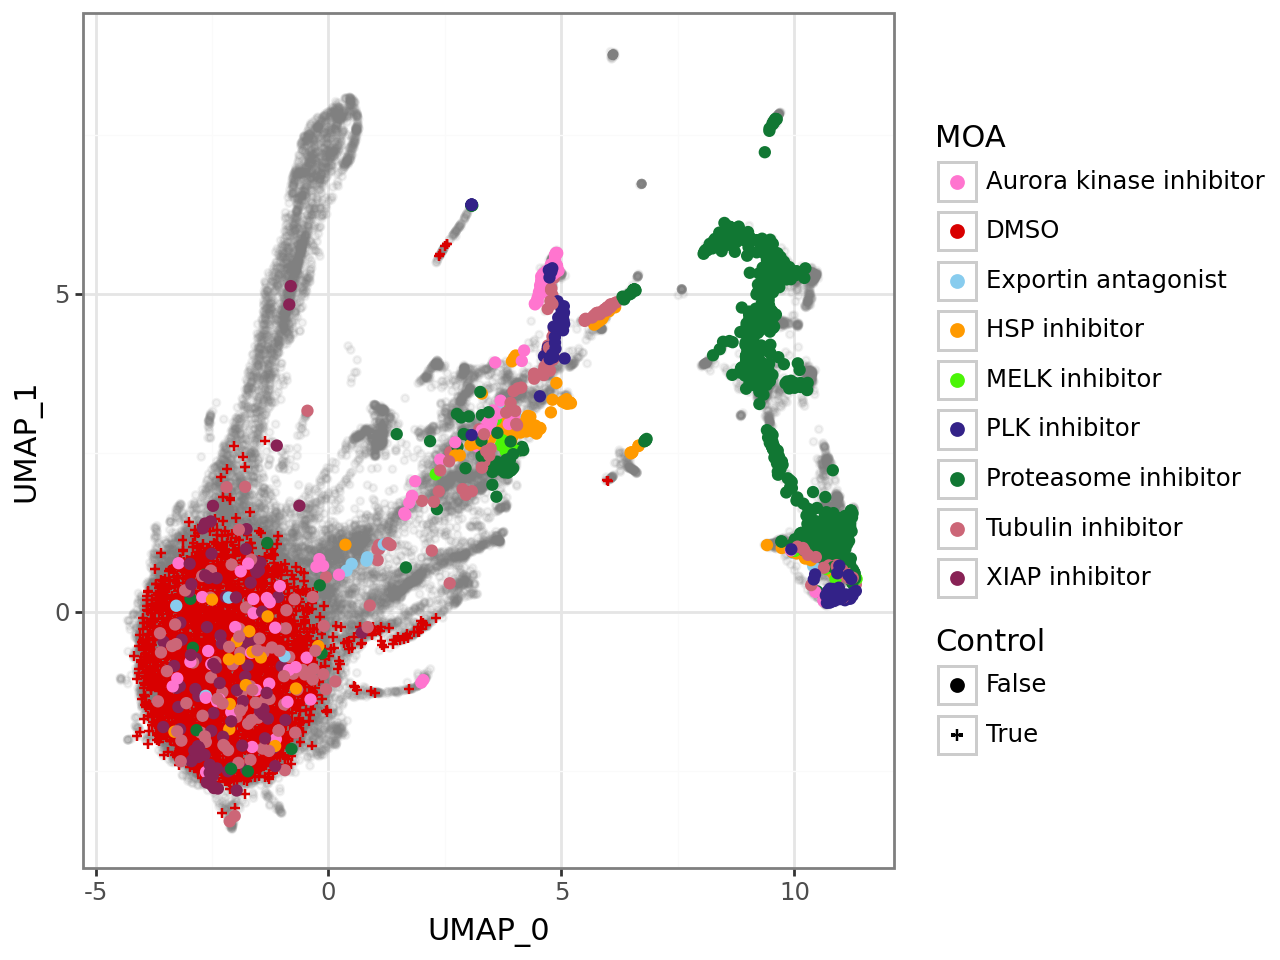

In [14]:
# 1. Create columns for plotting
post_qc_embedding_df["is_control"] = post_qc_embedding_df["dmso_label"] == "DMSO"

# Make a plotting MOA column so DMSO is separate from "Other"
post_qc_embedding_df["plot_moa"] = post_qc_embedding_df["highlight_moa"]
post_qc_embedding_df.loc[post_qc_embedding_df["dmso_label"] == "DMSO", "plot_moa"] = (
    "DMSO"
)

# Split datasets for layering
other_df = post_qc_embedding_df.query("highlight_moa == 'Other' & dmso_label != 'DMSO'")
main_df = post_qc_embedding_df.query("highlight_moa != 'Other' | dmso_label == 'DMSO'")

# 2. Build plot
p = (
    ggplot()
    # Layer 1: Other points in back, faint and small
    + geom_point(
        data=other_df,
        mapping=aes(x="UMAP_0", y="UMAP_1"),
        color=moa_colors["Other"],
        alpha=0.1,
        size=1,
        show_legend=False,
    )
    # Layer 2: All other MOAs + DMSO for correct legends
    + geom_point(
        data=main_df,
        mapping=aes(x="UMAP_0", y="UMAP_1", color="plot_moa", shape="is_control"),
    )
    # Titles and labels
    + xlab("UMAP_0")
    + ylab("UMAP_1")
    # Scales
    + scale_color_manual(name="MOA", values={**moa_colors, "DMSO": "#D80000"})
    + scale_shape_manual(name="Control", values={True: "+", False: "o"})
    # Guides
    + guides(
        shape=guide_legend(override_aes={"alpha": 1, "size": 2}),
        color=guide_legend(override_aes={"alpha": 1, "size": 2}),
    )
    # Theme
    + theme_bw()
)
p.save(filename=figure_output_dir / "post_qc_moa_umap.png", dpi=600)
p.show()